# Country-Level CO₂ Emissions Forecasting
## Time-Series Machine Learning Project

**Dataset:** Our World in Data CO₂ dataset  
**Target:** `co2`  
**Unit of analysis:** Country-year  
**Country identifier:** `iso_code`  
**Historical period:** 1950 onward

### Project purpose
This notebook develops a country-level time-series forecasting pipeline for annual CO₂ emissions. It follows the **CRISP-DM** methodology and deliberately separates past information from future information to avoid data leakage.

The project asks:

1. **How accurately can historical CO₂ emissions be used to predict future CO₂ emissions for individual countries?**
2. **Which economic, population and energy-related factors are most useful for predicting future CO₂ emissions?**
3. **How do CO₂ emission trends differ across countries over time?**
4. **Can a single forecasting model accurately predict CO₂ emissions across countries using ISO codes and historical characteristics?**
5. **Which time-series modelling approach provides the most accurate CO₂ forecasts?**
6. **How far into the future can CO₂ emissions be forecast with acceptable prediction accuracy?**
7. **Which countries are expected to experience increasing or decreasing CO₂ emissions based on historical trends?**

## 1. Business Understanding

### 1.1 Business problem

National CO₂ emissions are influenced by economic activity, population and energy use. The purpose of this project is to use historical country-level information to forecast **next-year CO₂ emissions** and identify patterns that can support emissions planning and monitoring.

### 1.2 Business objective

Develop an accurate, reproducible and interpretable forecasting approach for country-level CO₂ emissions using historical emissions, economic, population and energy-related variables.

### 1.3 Research questions

1. How accurately can historical CO₂ emissions predict future CO₂ emissions for individual countries?
2. Which economic, population and energy-related variables are useful for forecasting future CO₂ emissions?
3. How do CO₂ emission patterns differ across countries and over time?
4. Which forecasting model provides the best predictive performance?
5. Can the selected approach generate country-level forecasts for future years?

### 1.4 Metrics of success

The project will be considered successful when the modelling process: 
- uses a **chronological train/validation/test split** with no future information entering the training data;
- establishes a **naive persistence baseline** before applying machine-learning models;
- achieves lower **MAE** and **RMSE** than the baseline where possible;
- achieves a strong **R²** without relying on R² alone;
- demonstrates that missing values, duplicates and invalid values are handled systematically;
- compares several candidate models on the same validation period;
- uses **hyperparameter tuning** on the training data only;
- evaluates the selected model once on the untouched test period; and
- produces usable country-level forecasts for the next year.

**Metric interpretation:** MAE and RMSE should be minimised, while R² should be maximised. RMSE is particularly useful for identifying large forecasting errors because it penalises larger errors more heavily.

**Research context:** The project is informed by IPCC AR6 findings on socioeconomic and energy drivers of emissions and previous country-level CO₂ forecasting research such as Costantini et al. (2024).


## 2. Data Understanding

### 2.1. Data Source

The project uses the **Our World in Data (OWID) CO₂ and Greenhouse Gas Emissions Dataset**, which provides comprehensive country-level annual data from 1950 to 2024.

**Dataset characteristics**:
- **Coverage**: 250+ countries and regional aggregates
- **Time span**: 1950-2024 (75 years of historical data)
- **Update frequency**: Regular updates as new data becomes available
- **Format**: CSV with country, year, and multiple emission/socioeconomic indicators

### 2.2. Key Variables for Forecasting

**Target Variable**:
- `co2`: Total CO₂ emissions (in million tonnes)

**Primary Features** (grouped by category):

| Category | Variables | Purpose |
|----------|-----------|---------|
| **Temporal** | `year`, lagged CO₂ values | Capture time trends and momentum |
| **Demographic** | `population`, `population_density` | Control for country size and urbanization |
| **Economic** | `gdp`, `gdp_per_capita` | Proxy for economic activity level |
| **Energy** | `primary_energy_consumption`, `energy_per_capita`, `energy_intensity_level_of_ppp_gdp` | Reflect energy infrastructure and efficiency |
| **Emission Composition** | `coal_co2`, `oil_co2`, `gas_co2`, `cement_co2`, `flaring_co2` | Identify primary emission sources by fuel type |

### 2.3. Data Characteristics

- **Missing values**: Unevenly distributed across countries and time periods (e.g., developing nations have sparse early records)
- **Temporal ordering**: Sequential annual observations; must preserve temporal order in train/test splits
- **Scale variation**: Emissions range from near-zero (small island nations) to billions of tonnes (China, USA); requires normalization/scaling
- **Regional patterns**: Developed nations show stable/declining trends; emerging economies show growth; requires country-level modeling consideration

In [63]:
# Importing the neccesary libraries
import warnings
warnings.filterwarnings("ignore")

# Data manipulation
import pandas as pd
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Models
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor

In [64]:
# Loading the dataset
df_raw = pd.read_csv('owid-co2-data.csv')
df_raw.head()

,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,co2_including_luc,co2_including_luc_growth_abs,co2_including_luc_growth_prct,co2_including_luc_per_capita,co2_including_luc_per_gdp,co2_including_luc_per_unit_energy,co2_per_capita,co2_per_gdp,co2_per_unit_energy,coal_co2,coal_co2_per_capita,consumption_co2,consumption_co2_per_capita,consumption_co2_per_gdp,cumulative_cement_co2,cumulative_co2,cumulative_co2_including_luc,cumulative_coal_co2,cumulative_flaring_co2,cumulative_gas_co2,cumulative_luc_co2,cumulative_oil_co2,cumulative_other_co2,energy_per_capita,energy_per_gdp,flaring_co2,flaring_co2_per_capita,gas_co2,gas_co2_per_capita,ghg_excluding_lucf_per_capita,ghg_per_capita,land_use_change_co2,land_use_change_co2_per_capita,methane,methane_per_capita,nitrous_oxide,nitrous_oxide_per_capita,oil_co2,oil_co2_per_capita,other_co2_per_capita,other_industry_co2,primary_energy_consumption,share_global_cement_co2,share_global_co2,share_global_co2_including_luc,share_global_coal_co2,share_global_cumulative_cement_co2,share_global_cumulative_co2,share_global_cumulative_co2_including_luc,share_global_cumulative_coal_co2,share_global_cumulative_flaring_co2,share_global_cumulative_gas_co2,share_global_cumulative_luc_co2,share_global_cumulative_oil_co2,share_global_cumulative_other_co2,share_global_flaring_co2,share_global_gas_co2,share_global_luc_co2,share_global_oil_co2,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Afghanistan,1750,AFG,2802560.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1751,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1752,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,1753,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,1754,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [65]:
# Checking the shape of the dataset
df_raw.shape

(50411, 79)

This dataset contains **50411** rows and **79** columns

In [66]:
# Checking the datatypes of the columns
df_raw.dtypes

country                                          str
year                                           int64
iso_code                                         str
population                                   float64
gdp                                          float64
cement_co2                                   float64
cement_co2_per_capita                        float64
co2                                          float64
co2_growth_abs                               float64
co2_growth_prct                              float64
co2_including_luc                            float64
co2_including_luc_growth_abs                 float64
co2_including_luc_growth_prct                float64
co2_including_luc_per_capita                 float64
co2_including_luc_per_gdp                    float64
co2_including_luc_per_unit_energy            float64
co2_per_capita                               float64
co2_per_gdp                                  float64
co2_per_unit_energy                          f

Most of the columns in the dataset are numerical (int 64 & float 64) and there are two columns which are string datatype which are country and iso_code.

The year is int 64 instead of datetime so we'll have to change to datetime.

In [67]:
# Checking the information of the dataset
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 50411 entries, 0 to 50410
Data columns (total 79 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   country                                    50411 non-null  str    
 1   year                                       50411 non-null  int64  
 2   iso_code                                   42480 non-null  str    
 3   population                                 41167 non-null  float64
 4   gdp                                        15251 non-null  float64
 5   cement_co2                                 29173 non-null  float64
 6   cement_co2_per_capita                      25648 non-null  float64
 7   co2                                        29384 non-null  float64
 8   co2_growth_abs                             27216 non-null  float64
 9   co2_growth_prct                            26239 non-null  float64
 10  co2_including_luc                

It appears that there are missing data in the dataset.

In [68]:
# Checking for missing data (count and percentage)
missing_summary = pd.DataFrame({
    'Missing Count': df_raw.isna().sum(),
    'Missing Percent': df_raw.isna().mean() * 100
})

missing_summary['Combined'] = (
    missing_summary['Missing Count'].astype(str)
    + " ("
    + missing_summary['Missing Percent'].round(2).astype(str)
    + "%)"
)

missing_summary.round(2)

,Missing Count,Missing Percent,Combined
country,0,0.00,0 (0.0%)
year,0,0.00,0 (0.0%)
iso_code,7931,15.73,7931 (15.73%)
population,9244,18.34,9244 (18.34%)
gdp,35160,69.75,35160 (69.75%)
cement_co2,21238,42.13,21238 (42.13%)
cement_co2_per_capita,24763,49.12,24763 (49.12%)
co2,21027,41.71,21027 (41.71%)
co2_growth_abs,23195,46.01,23195 (46.01%)
co2_growth_prct,24172,47.95,24172 (47.95%)


The above are the number of missing data and their percentage of every column in the dataset.

This dataset has alot of missing data some columns even has as far as 90% missing data. We'll have to take a closer look at the data and remove some columns if necessary.

In [69]:
# Checking the feature/column names
df_raw.columns

Index(['country', 'year', 'iso_code', 'population', 'gdp', 'cement_co2',
       'cement_co2_per_capita', 'co2', 'co2_growth_abs', 'co2_growth_prct',
       'co2_including_luc', 'co2_including_luc_growth_abs',
       'co2_including_luc_growth_prct', 'co2_including_luc_per_capita',
       'co2_including_luc_per_gdp', 'co2_including_luc_per_unit_energy',
       'co2_per_capita', 'co2_per_gdp', 'co2_per_unit_energy', 'coal_co2',
       'coal_co2_per_capita', 'consumption_co2', 'consumption_co2_per_capita',
       'consumption_co2_per_gdp', 'cumulative_cement_co2', 'cumulative_co2',
       'cumulative_co2_including_luc', 'cumulative_coal_co2',
       'cumulative_flaring_co2', 'cumulative_gas_co2', 'cumulative_luc_co2',
       'cumulative_oil_co2', 'cumulative_other_co2', 'energy_per_capita',
       'energy_per_gdp', 'flaring_co2', 'flaring_co2_per_capita', 'gas_co2',
       'gas_co2_per_capita', 'ghg_excluding_lucf_per_capita', 'ghg_per_capita',
       'land_use_change_co2', 'land_use_chang

The above is all the names of the columns in this dataset.

In [70]:
# checking the description of the dataset
df_raw.describe()

,year,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,co2_including_luc,co2_including_luc_growth_abs,co2_including_luc_growth_prct,co2_including_luc_per_capita,co2_including_luc_per_gdp,co2_including_luc_per_unit_energy,co2_per_capita,co2_per_gdp,co2_per_unit_energy,coal_co2,coal_co2_per_capita,consumption_co2,consumption_co2_per_capita,consumption_co2_per_gdp,cumulative_cement_co2,cumulative_co2,cumulative_co2_including_luc,cumulative_coal_co2,cumulative_flaring_co2,cumulative_gas_co2,cumulative_luc_co2,cumulative_oil_co2,cumulative_other_co2,energy_per_capita,energy_per_gdp,flaring_co2,flaring_co2_per_capita,gas_co2,gas_co2_per_capita,ghg_excluding_lucf_per_capita,ghg_per_capita,land_use_change_co2,land_use_change_co2_per_capita,methane,methane_per_capita,nitrous_oxide,nitrous_oxide_per_capita,oil_co2,oil_co2_per_capita,other_co2_per_capita,other_industry_co2,primary_energy_consumption,share_global_cement_co2,share_global_co2,share_global_co2_including_luc,share_global_coal_co2,share_global_cumulative_cement_co2,share_global_cumulative_co2,share_global_cumulative_co2_including_luc,share_global_cumulative_coal_co2,share_global_cumulative_flaring_co2,share_global_cumulative_gas_co2,share_global_cumulative_luc_co2,share_global_cumulative_oil_co2,share_global_cumulative_other_co2,share_global_flaring_co2,share_global_gas_co2,share_global_luc_co2,share_global_oil_co2,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
count,50411.000000,4.116700e+04,1.525100e+04,29173.000000,25648.000000,29384.000000,27216.000000,26239.000000,23796.000000,23496.000000,23496.000000,23757.000000,16790.000000,10133.000000,26509.000000,17528.000000,10826.000000,21925.000000,21314.000000,5053.000000,4643.000000,4448.000000,29151.000000,2.756300e+04,2.379600e+04,21925.000000,16111.000000,18147.000000,37450.000000,25458.000000,3254.000000,10586.000000,7787.000000,16174.000000,14910.000000,18147.000000,17446.000000,35842.00000,36179.000000,37450.000000,36635.000000,38150.000000,36179.000000,38500.000000,36439.000000,25459.000000,24722.000000,2659.000000,3254.000000,10631.000000,22270.000000,27563.000000,23796.000000,21925.000000,22270.000000,27563.000000,23796.000000,21925.000000,11089.000000,15167.000000,37450.000000,23833.000000,2170.000000,11089.000000,15167.000000,37450.000000,23833.000000,2170.000000,41238.000000,38280.000000,41238.000000,41238.000000,38280.000000,38150.000000,37813.000000,4712.000000,4712.000000
mean,1920.349249,6.017294e+07,3.300495e+11,7.890109,0.060026,420.227035,6.268847,42.598225,544.144592,7.483698,4.132343,7.115447,2.328426,1343.224898,3.821411,0.397679,251.177589,185.496070,1.285324,1318.129607,6.463631,0.349924,196.486344,1.249223e+04,2.790247e+04,9311.023979,177.231149,1876.820098,9998.375654,3777.605153,417.861562,24218.017776,1.672906,5.854644,0.270544,74.840369,0.797032,3.07991,7.716833,124.752927,3.905510,95.277707,1.741468,25.424751,0.444591,115.307630,2.192718,0.082205,20.116569,2450.931544,3.002813,5.369860,3.457512,6.791725,2.995657,5.500642,3.321957,6.974350,3.043673,4.104541,2.559362,3.351795,7.053671,3.126383,4.195698,2.439717,3.333339,7.190616,2.272236,0.002871,0.008014,0.011224,0.000509,490.799608,310.521459,-6.986781,21.468641
std,65.859123,3.308412e+08,3.086383e+12,62.988171,0.123566,1972.092032,62.199548,1721.913018,2273.281696,99.512520,166.964358,8.921137,5.626872,6678.225759,14.312856,0.754065,315.226128,855.418419,2.351089,3904.104954,6.852299,0.247281,1495.918343,7.312143e+04,1.269563e+05,43499.981365,926.732659,11756.922691,46043.141427,24886.829185,1317.317547,32203.518384,1.629769,26.749898,2.995049,397.296985,2.805144,7.78545,11.276765,519.818810,9.106597,434.707032,3.832696,129.896895,0.799286,646.556645,13.948769,0.079726,55.644708,11383.276535,13.389959,18.734892,11.709725,20.969463

The dataset appears to have skewed features/columns and we'll have to consider during cleaning

### 3.1 Missing-value assessment — first cleaning step

Missing values are assessed before dropping or imputing anything. This prevents important information from being removed without understanding where and why values are missing. The target variable (`co2`) is treated differently from predictors: rows without a usable target cannot contribute to supervised training, while missing predictor values can later be handled by the preprocessing pipeline.


In [71]:
# Missing-value audit on the raw dataset
missing_summary = pd.DataFrame({
    'Missing Count': df_raw.isna().sum(),
    'Missing Percentage': (df_raw.isna().mean() * 100).round(2)
}).sort_values('Missing Percentage', ascending=False)

missing_summary.head(20)

,Missing Count,Missing Percentage
share_global_cumulative_other_co2,48241,95.70
share_global_other_co2,48241,95.70
other_co2_per_capita,47752,94.73
cumulative_other_co2,47157,93.55
other_industry_co2,47157,93.55
consumption_co2_per_gdp,45963,91.18
consumption_co2_per_capita,45768,90.79
trade_co2,45699,90.65
trade_co2_share,45699,90.65
consumption_co2,45358,89.98


### 3.2 Duplicate assessment

For a country-level annual time series, each **country-year** should represent one observation. Duplicate country-year records can distort trends, correlations and lag calculations, so they must be identified and removed before time-series preprocessing.


In [72]:
# Check duplicate country-year observations
duplicate_count = df_raw.duplicated(subset=['iso_code', 'year']).sum()
print('Duplicate country-year rows:', duplicate_count)

# Inspect duplicate country-year records if any exist
duplicates = df_raw[df_raw.duplicated(subset=['iso_code', 'year'], keep=False)].sort_values(['iso_code', 'year'])
duplicates.head(20)

Duplicate country-year rows: 7656


,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,co2_including_luc,co2_including_luc_growth_abs,co2_including_luc_growth_prct,co2_including_luc_per_capita,co2_including_luc_per_gdp,co2_including_luc_per_unit_energy,co2_per_capita,co2_per_gdp,co2_per_unit_energy,coal_co2,coal_co2_per_capita,consumption_co2,consumption_co2_per_capita,consumption_co2_per_gdp,cumulative_cement_co2,cumulative_co2,cumulative_co2_including_luc,cumulative_coal_co2,cumulative_flaring_co2,cumulative_gas_co2,cumulative_luc_co2,cumulative_oil_co2,cumulative_other_co2,energy_per_capita,energy_per_gdp,flaring_co2,flaring_co2_per_capita,gas_co2,gas_co2_per_capita,ghg_excluding_lucf_per_capita,ghg_per_capita,land_use_change_co2,land_use_change_co2_per_capita,methane,methane_per_capita,nitrous_oxide,nitrous_oxide_per_capita,oil_co2,oil_co2_per_capita,other_co2_per_capita,other_industry_co2,primary_energy_consumption,share_global_cement_co2,share_global_co2,share_global_co2_including_luc,share_global_coal_co2,share_global_cumulative_cement_co2,share_global_cumulative_co2,share_global_cumulative_co2_including_luc,share_global_cumulative_coal_co2,share_global_cumulative_flaring_co2,share_global_cumulative_gas_co2,share_global_cumulative_luc_co2,share_global_cumulative_oil_co2,share_global_cumulative_other_co2,share_global_flaring_co2,share_global_gas_co2,share_global_luc_co2,share_global_oil_co2,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
275,Africa,1750,NaN,79382032.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2679,Asia,1750,NaN,498699232.0,NaN,0.0,0.0,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.000,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3129,Asia (excl. China and India),1750,NaN,NaN,NaN,0.0,0.0,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.000,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14993,Europe,1750,NaN,154836912.0,NaN,0.0,0.0,9.306,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.062,NaN,NaN,9.306,0.062,NaN,NaN,NaN,0.0,9.306,NaN,9.306,0.0,0.0,NaN,0.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,100.0,NaN,100.0,NaN,100.0,NaN,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15443,Europe (excl. EU-27),1750,NaN,NaN,NaN,0.0,0.0,9.306,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.214,NaN,NaN,9.306,0.214,NaN,NaN,NaN,0.0,9.306,NaN,9.306,0.0,0.0,NaN,0.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,100.0,NaN,100.0,NaN,100.0,NaN,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15718,Europe (excl. EU-28),1750,NaN,NaN,NaN,0.0,0.0,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.000,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15993,European Union (27),1750,NaN,106479340.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

### 3.3 Invalid and inconsistent values

Infinite values can arise from ratios or calculations and are not valid model inputs. They are converted to `NaN` so that they can be handled consistently. Country records without an ISO code are excluded because the project models countries rather than aggregates such as continents or income groups.


In [73]:
# Check invalid infinite values before further cleaning
infinite_counts = pd.Series(np.isinf(df_raw.select_dtypes(include=np.number)).sum())
infinite_counts[infinite_counts > 0].sort_values(ascending=False).head(20)

Series([], dtype: int64)

## 3. Data Cleaning

**Data cleaning is different from time-series preprocessing.**

- **Data cleaning** makes the raw dataset reliable: missing-value assessment, duplicate detection/removal, invalid-value checks, incorrect records, country filtering and removal of unsuitable observations.
- **Time-series preprocessing** prepares the already-clean data for modelling: chronological ordering, creating the forecasting target, aligning lags/rolling windows, encoding categorical variables, imputing model features and applying transformations inside a modelling pipeline.

The cleaning stage is completed before modelling features are constructed.


### 3.4 Country filtering and duplicate removal

Keep observations with a valid ISO code and remove duplicate country-year observations. This creates one chronological observation per country per year before the historical period and variable-selection steps.


In [74]:
# Keep country-level observations and remove duplicate country-year records
df_countries = df_raw[df_raw['iso_code'].notna()].copy()
df_countries = df_countries.drop_duplicates(subset=['iso_code', 'year'], keep='first')

print('Rows after country filtering and duplicate removal:', len(df_countries))
print('Remaining duplicate country-year rows:', df_countries.duplicated(subset=['iso_code', 'year']).sum())

Rows after country filtering and duplicate removal: 42480
Remaining duplicate country-year rows: 0


### 3.5 Correlation assessment

Correlation is assessed after the basic structural cleaning steps. It is used as an **exploratory screening tool**, not as proof of causation. Strongly related variables are investigated because highly redundant predictors can add noise or instability, while variables with useful relationships to CO₂ can inform feature selection and modelling.


In [75]:
# Correlation of numeric variables with the CO2 target
target = 'co2'
correlations = (
    df_countries.select_dtypes(include='number')
    .corr()[target]
    .sort_values(ascending=False)
)

correlations

co2                                          1.000000
total_ghg_excluding_lucf                     0.998848
consumption_co2                              0.993112
primary_energy_consumption                   0.988604
total_ghg                                    0.953452
co2_including_luc                            0.951048
share_global_other_co2                       0.950661
gdp                                          0.924912
coal_co2                                     0.923477
cumulative_coal_co2                          0.893168
other_industry_co2                           0.889258
share_global_cumulative_other_co2            0.884977
temperature_change_from_ghg                  0.882681
nitrous_oxide                                0.880835
oil_co2                                      0.874346
temperature_change_from_ch4                  0.868975
cumulative_cement_co2                        0.866290
cumulative_co2_including_luc                 0.864406
temperature_change_from_n2o 

### 3.6 Selecting variables for the forecasting dataset

The selected variables represent the main dimensions expected to help explain or predict CO₂ emissions: country identity, time, population, economic activity, energy use and emissions-related variables. Variables are retained based on forecasting relevance, data availability and exploratory relationships rather than correlation alone.


In [76]:
# List of the columns to keep
columns_to_keep = ['country', 'year', 'iso_code', 'gdp', 'population', 'co2', 'co2_per_capita', 'flaring_co2', 'cement_co2', 'coal_co2', 'oil_co2', 'gas_co2', 'land_use_change_co2', 'total_ghg', 'other_industry_co2','primary_energy_consumption', 'energy_per_capita','co2_including_luc']

# Keeping relevant columns
df1 = df_countries[columns_to_keep]

### 3.4. Restrict the Historical Period

#### 3.4.1. Checking the missing data by year

In [77]:
# Calculate the overall missing percentage across all other columns per year
missing_pct_by_year = df1.groupby('year').apply(
    lambda x: (x.drop(columns=['year'], errors='ignore').isna().sum().sum() / # sum of missing values across all columns except 'year'
               x.drop(columns=['year'], errors='ignore').size) * 100, # to percent
    include_groups=False # do not include the group keys in the output
)
print(missing_pct_by_year)

year
1750    74.509804
1751    80.693816
1752    80.693816
1753    80.693816
1754    80.693816
1755    80.693816
1756    80.693816
1757    80.693816
1758    80.693816
1759    80.693816
1760    74.509804
1761    80.693816
1762    80.693816
1763    80.693816
1764    80.693816
1765    80.693816
1766    80.693816
1767    80.693816
1768    80.693816
1769    80.693816
1770    74.509804
1771    80.693816
1772    80.693816
1773    80.693816
1774    80.693816
1775    80.693816
1776    80.693816
1777    80.693816
1778    80.693816
1779    80.693816
1780    74.509804
1781    80.693816
1782    80.693816
1783    80.693816
1784    80.693816
1785    80.294118
1786    80.294118
1787    80.294118
1788    80.294118
1789    80.294118
1790    73.970588
1791    80.294118
1792    79.913917
1793    79.913917
1794    79.913917
1795    79.913917
1796    79.913917
1797    79.913917
1798    79.913917
1799    79.913917
1800    72.093023
1801    72.366621
1802    71.503268
1803    72.366621
1804    71.925134
1805 

#### Why remove years before 1950?
The project focuses on the modern period in which economic activity, energy systems and emissions data are more relevant to contemporary forecasting. Earlier historical observations also contain substantially more gaps and can make comparisons across countries less consistent.

Therefore, this project uses **1950 onward**.

#### 3.4.2. Removing the years before 1950

In [78]:
# Ensure the 'year' column is of datetime type
df1['year'] = pd.to_datetime(df1['year'], format='%Y').dt.year

# Keep years from 1950 onwards
df1 = df1[df1["year"] >= 1950]

In [79]:
# Checking for missing data of df1
missing_summary = pd.DataFrame({
    'Missing Count': df1.isna().sum(),
    'Missing Percent': df1.isna().mean() * 100
})

missing_summary['Combined'] = (
    missing_summary['Missing Count'].astype(str)
    + " ("
    + missing_summary['Missing Percent'].round(2).astype(str)
    + "%)"
)

missing_summary.round(2)

,Missing Count,Missing Percent,Combined
country,0,0.00,0 (0.0%)
year,0,0.00,0 (0.0%)
iso_code,0,0.00,0 (0.0%)
gdp,4893,29.93,4893 (29.93%)
population,150,0.92,150 (0.92%)
co2,1080,6.61,1080 (6.61%)
co2_per_capita,1163,7.11,1163 (7.11%)
flaring_co2,6697,40.96,6697 (40.96%)
cement_co2,1460,8.93,1460 (8.93%)
coal_co2,5843,35.74,5843 (35.74%)


In [80]:
# get ratio of missing co2 values for each country
missing_co2_by_country = df1.groupby('country')['co2'].apply(lambda x: x.isnull().mean())
missing_co2_by_country.sort_values(ascending=False)

country
San Marino                          1.000000
Monaco                              1.000000
Vatican                             1.000000
East Timor                          0.586667
Eritrea                             0.586667
Marshall Islands                    0.560000
Micronesia (country)                0.560000
Namibia                             0.546667
Anguilla                            0.533333
Andorra                             0.533333
Lesotho                             0.533333
Palestine                           0.533333
Turks and Caicos Islands            0.533333
Tuvalu                              0.533333
Wallis and Futuna                   0.533333
Antarctica                          0.493333
Saint Helena                        0.400000
Christmas Island                    0.400000
Botswana                            0.293333
Maldives                            0.280000
Niue                                0.266667
Bhutan                              0.266667
Co

In [81]:
# Create a working copy for cleaning
df_cleaned = df1.copy()

## 4. Time-Series Preprocessing

This stage is deliberately separated from general data cleaning. The dataset has already been checked for structural quality. Time-series preprocessing now transforms the cleaned records into a form suitable for forecasting while preserving temporal order and preventing future information from leaking into the past.

### 4.1 Preprocessing steps

1. Restrict the modelling period to the selected historical years.
2. Sort observations chronologically within each country.
3. Replace remaining infinite values with `NaN`.
4. Remove countries with no usable CO₂ observations.
5. Create time-aware lag, rolling and growth features.
6. Create the next-year forecasting target.
7. Impute missing predictor values inside the modelling pipeline.
8. Encode the country identifier without manually leaking future information.

**Important:** Missing predictor values are not filled using future observations. Imputation is fitted on the training data through the scikit-learn pipeline and then applied to validation, test and future data.


### 4.2 Time-series preprocessing function

The preprocessing function prepares the cleaned dataset for forecasting. It focuses on **temporal structure** rather than repeating the raw-data cleaning tasks.

The chronological ordering is essential because lagged and rolling variables must only use information that would have been available at the prediction date.


In [82]:
def preprocessing_pipeline(data):
    data = data.copy()

    # Time-series preprocessing: preserve chronological structure
    data = data[data['year'] >= 1950].copy()
    data = data.replace([np.inf, -np.inf], np.nan)
    data = data.sort_values(['country', 'year'])

    # Keep countries that contain at least one CO2 observation
    data = data.groupby('country', group_keys=False).filter(
        lambda x: x['co2'].notna().any()
    )

    return data

In [83]:
missing_summary = pd.DataFrame({
    'Missing Count': df_cleaned.isna().sum(),
    'Missing Percentage': (
        df_cleaned.isna().mean() * 100
    )
})

missing_summary = (
    missing_summary
    .sort_values('Missing Percentage', ascending=False)
)

missing_summary

,Missing Count,Missing Percentage
other_industry_co2,14662,89.675841
gas_co2,8343,51.027523
flaring_co2,6697,40.960245
energy_per_capita,6486,39.669725
primary_energy_consumption,6441,39.394495
coal_co2,5843,35.737003
gdp,4893,29.926606
co2_including_luc,2405,14.709480
land_use_change_co2,1575,9.633028
cement_co2,1460,8.929664


In [84]:
# Getting the information of the cleaned dataset
df_cleaned.info()

<class 'pandas.DataFrame'>
Index: 16350 entries, 200 to 50410
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   country                     16350 non-null  str    
 1   year                        16350 non-null  int32  
 2   iso_code                    16350 non-null  str    
 3   gdp                         11457 non-null  float64
 4   population                  16200 non-null  float64
 5   co2                         15270 non-null  float64
 6   co2_per_capita              15187 non-null  float64
 7   flaring_co2                 9653 non-null   float64
 8   cement_co2                  14890 non-null  float64
 9   coal_co2                    10507 non-null  float64
 10  oil_co2                     15168 non-null  float64
 11  gas_co2                     8007 non-null   float64
 12  land_use_change_co2         14775 non-null  float64
 13  total_ghg                   14925 non-null  f

In [85]:
missing_pct_by_year = df_cleaned.groupby('country')['co2'].apply(
    lambda x: (x.isna().sum() / x.size) * 100, # to percent
    include_groups=False # do not include the group keys in the output
).sort_values(ascending=False)
print(missing_pct_by_year)

country
San Marino                          100.000000
Monaco                              100.000000
Vatican                             100.000000
East Timor                           58.666667
Eritrea                              58.666667
Marshall Islands                     56.000000
Micronesia (country)                 56.000000
Namibia                              54.666667
Anguilla                             53.333333
Andorra                              53.333333
Lesotho                              53.333333
Palestine                            53.333333
Turks and Caicos Islands             53.333333
Tuvalu                               53.333333
Wallis and Futuna                    53.333333
Antarctica                           49.333333
Saint Helena                         40.000000
Christmas Island                     40.000000
Botswana                             29.333333
Maldives                             28.000000
Niue                                 26.666667
Bhuta

In [86]:
# Remove countries with over 30% missing data in the 'co2' column
missing_co2_by_country = df_cleaned.groupby('country')['co2'].apply(lambda x: x.isnull().mean())
countries_to_remove = missing_co2_by_country[missing_co2_by_country > 0.3].index
df_cleaned = df_cleaned[~df_cleaned['country'].isin(countries_to_remove)]

We have countries that would hinder the modelling phase with too little data so we removed them. 

## 5. Exploratory Data Analysis (EDA)

EDA is performed at three levels: **univariate, bivariate and multivariate**. This helps understand individual variable distributions, pairwise relationships and interactions among several variables before final modelling.

### 5.1 Univariate EDA

Univariate analysis examines one variable at a time. For this project it is used to understand the distribution, scale, skewness and extreme values of CO₂ emissions, GDP, population and energy consumption. This is important because CO₂ data are highly uneven across countries and large emitters can dominate absolute values.


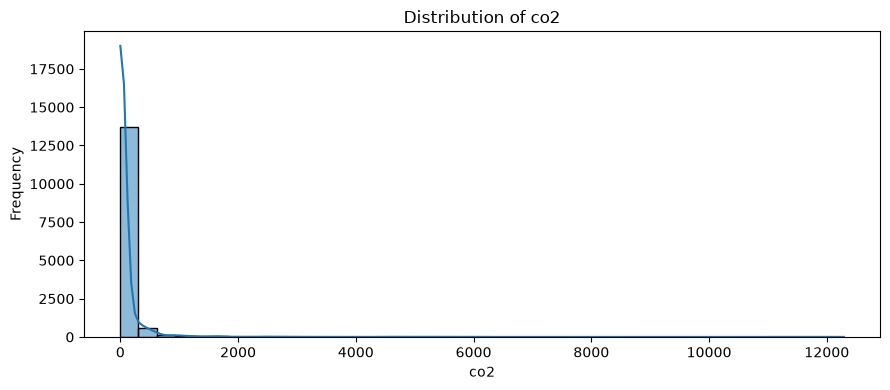

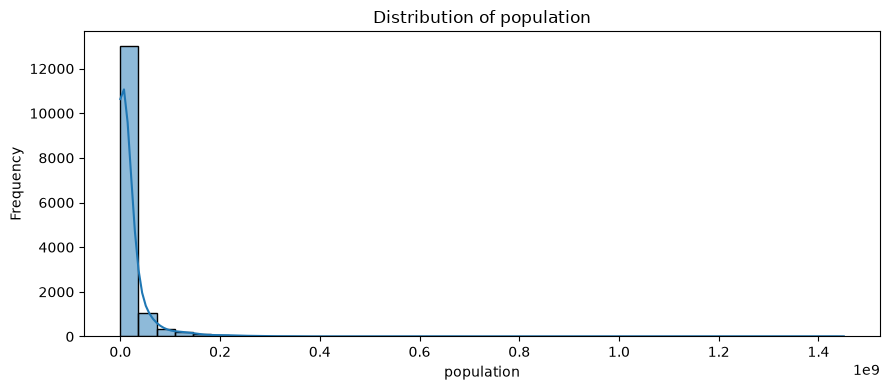

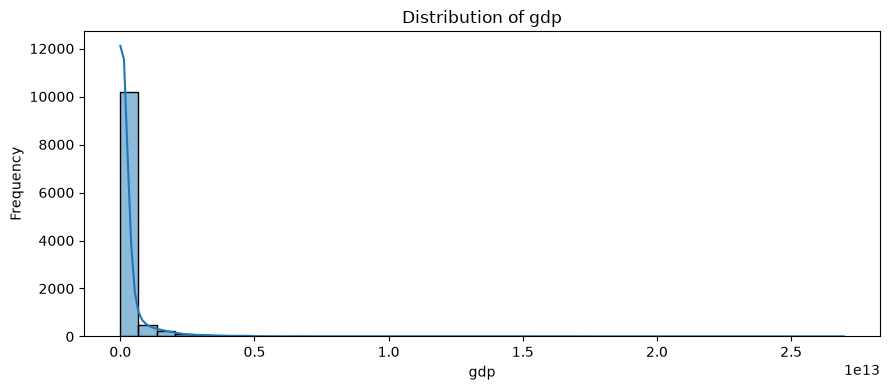

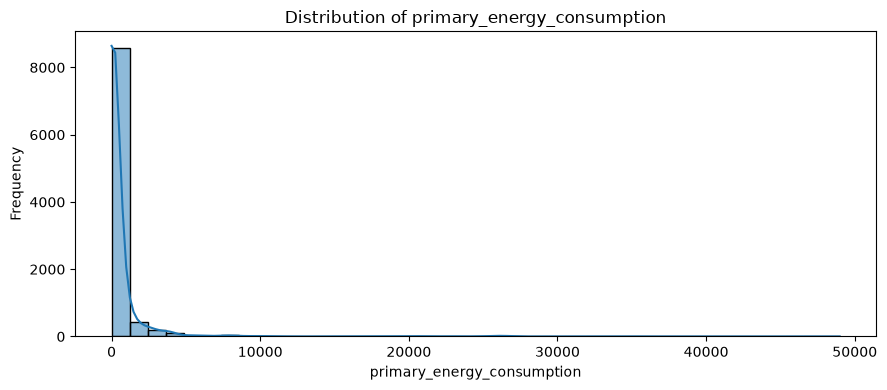

In [87]:
# Univariate EDA: distribution of key numerical variables
eda_cols = ['co2', 'population', 'gdp', 'primary_energy_consumption']

for col in eda_cols:
    if col in df_cleaned.columns:
        plt.figure(figsize=(9, 4))
        sns.histplot(df_cleaned[col].dropna(), bins=40, kde=True)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.tight_layout()
        plt.show()

### 5.2 Bivariate EDA: CO₂ over time

A time-series line plot examines the relationship between **year and CO₂ emissions**. This identifies long-term trends, periods of rapid growth or decline and the strong persistence that motivates a naive forecasting benchmark.


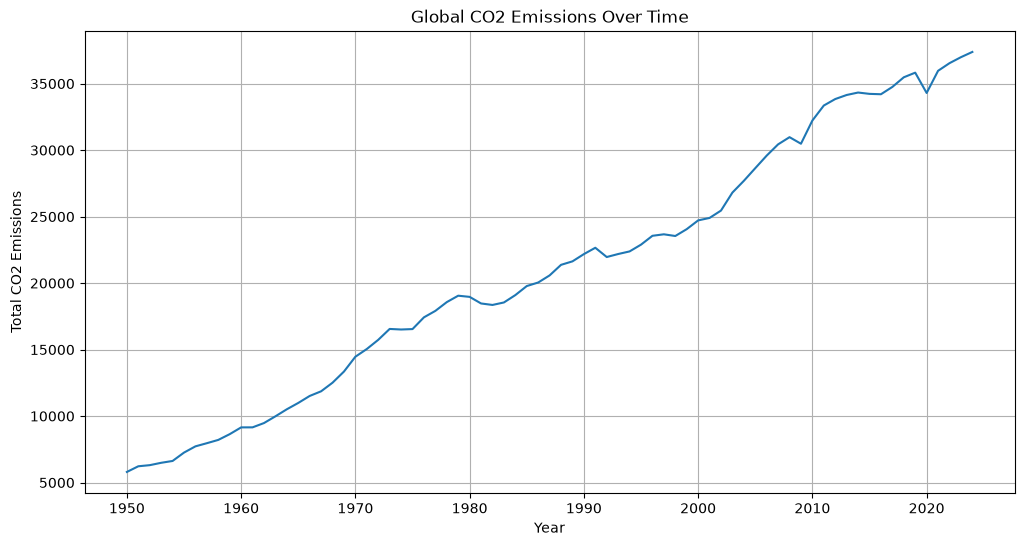

In [88]:
# create a line plot that shows the total co2 emissions over time. i want to show the global emissions.
df_global = df_cleaned.groupby('year')['co2'].sum().reset_index()

plt.figure(figsize=(12,6))
plt.plot(df_global['year'], df_global['co2'])
plt.title('Global CO2 Emissions Over Time')
plt.xlabel('Year')
plt.ylabel('Total CO2 Emissions')
plt.grid(True)
plt.show()

Global CO₂ emissions show a strong long-term upward trend, rising substantially from 1950 to the most recent years. The main noticeable declines occur around the early 1980s and early 1990s, periods associated with economic slowdowns and reduced energy demand. A sharper decline occurs around 2009 following the global financial crisis, while the largest recent drop is around 2020, largely associated with COVID-19 restrictions that temporarily reduced transportation, industrial activity, and energy use. Emissions rebounded quickly afterward and reached new highs, showing that the overall long-term trend remains upward.

### 5.3 Bivariate EDA: Country and cumulative CO₂ emissions

Comparing country-level cumulative emissions shows how unevenly emissions are distributed across countries and highlights the importance of retaining country identity as a categorical forecasting feature.


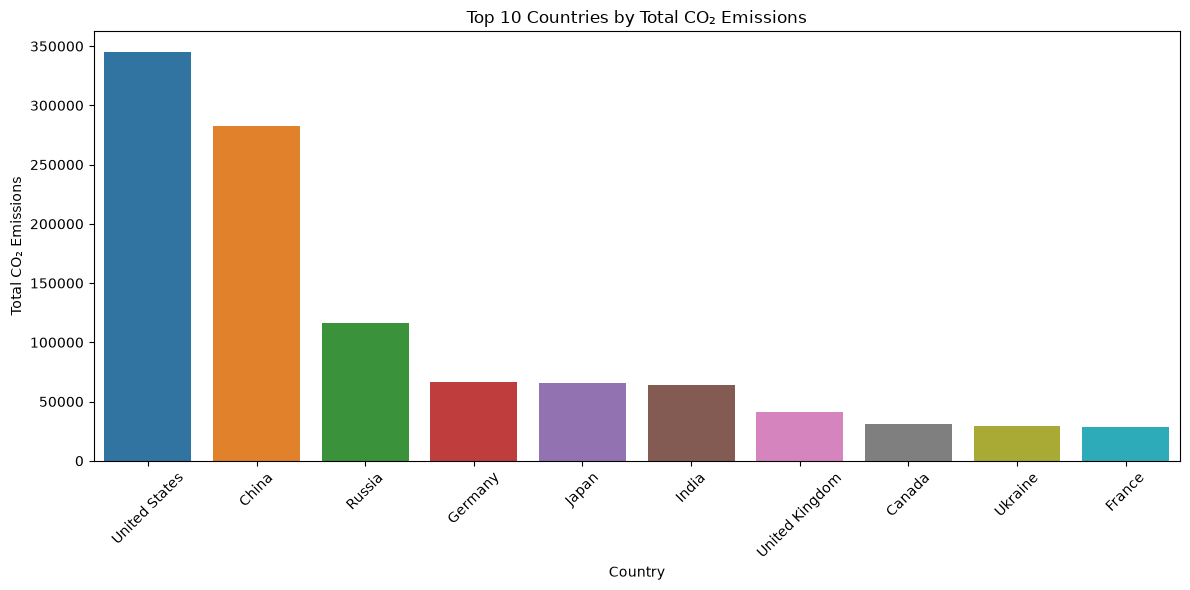

In [89]:
top_emitters = df_cleaned.groupby("country")["co2"].sum().nlargest(10)


# Create a consistent color palette
colors = sns.color_palette("tab10", n_colors=len(top_emitters))
# Map each country to its assigned color
country_colors = dict(zip(top_emitters.index, colors))


plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_emitters.index,
    y=top_emitters.values,
    palette=country_colors
)

plt.title("Top 10 Countries by Total CO₂ Emissions")
plt.xlabel("Country")
plt.ylabel("Total CO₂ Emissions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The analysis of cumulative CO₂ emissions shows that the **United States is among the largest contributors to total emissions** over the study period. This highlights the significant role of highly industrialized economies in historical global emissions and shows the large differences in emission levels across countries.

### 5.4 Bivariate EDA: CO₂ trends by country

Country-specific time-series plots compare the direction and rate of change among major emitters. Different trajectories demonstrate why a model needs both temporal information and country-level characteristics.


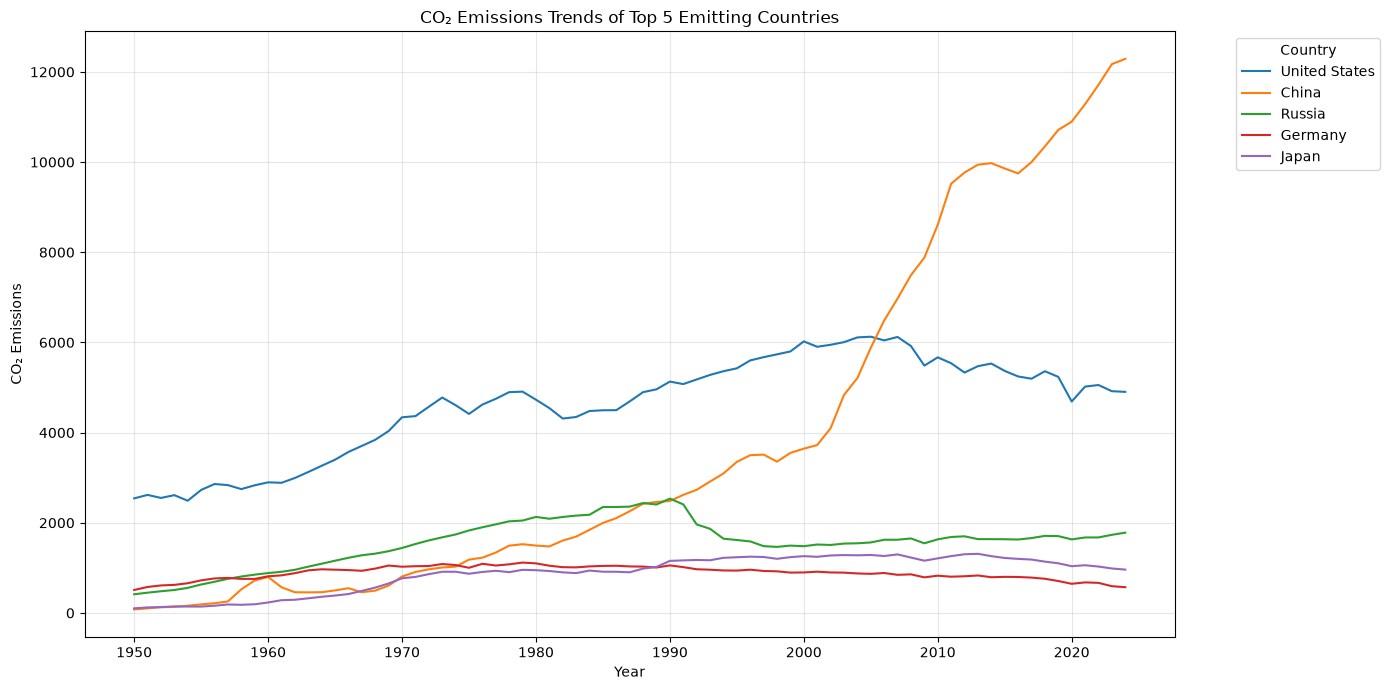

In [90]:
# Identify the top 5 countries by total CO₂ emissions
top_5_countries = top_emitters.head(5).index

top_countries_df = df_cleaned[
    df_cleaned["country"].isin(top_5_countries)
]

plt.figure(figsize=(14, 7))

# Plot each country separately
for country in top_5_countries:
    country_data = top_countries_df[
        top_countries_df["country"] == country
    ].sort_values("year")

    plt.plot(
        country_data["year"],
        country_data["co2"],
        label=country
    )

plt.title("CO₂ Emissions Trends of Top 5 Emitting Countries")
plt.xlabel("Year")
plt.ylabel("CO₂ Emissions")

plt.legend(
    title="Country",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

The CO₂ emissions trend shows different patterns among the major emitting countries. The **United States experienced strong emissions growth historically, but its emissions have remained relatively stable and have declined in more recent years**. This can be associated with slower growth in energy demand, improvements in energy efficiency, a shift away from coal, and increased use of cleaner energy sources.

In contrast, **China's CO₂ emissions increased rapidly, particularly from the early 2000s**. This reflects China's rapid industrialization, economic growth, expansion of manufacturing, urbanization, and heavy dependence on coal for energy.

The comparison shows that CO₂ emissions can change significantly as countries move through different stages of **economic development, industrialization, and energy transition**.

### 5.5 Multivariate EDA: Correlation among emissions, energy and economic variables

The multivariate correlation matrix examines several variables simultaneously. It helps identify groups of strongly related predictors, possible redundancy and the broader relationship between CO₂, energy consumption, GDP and population.


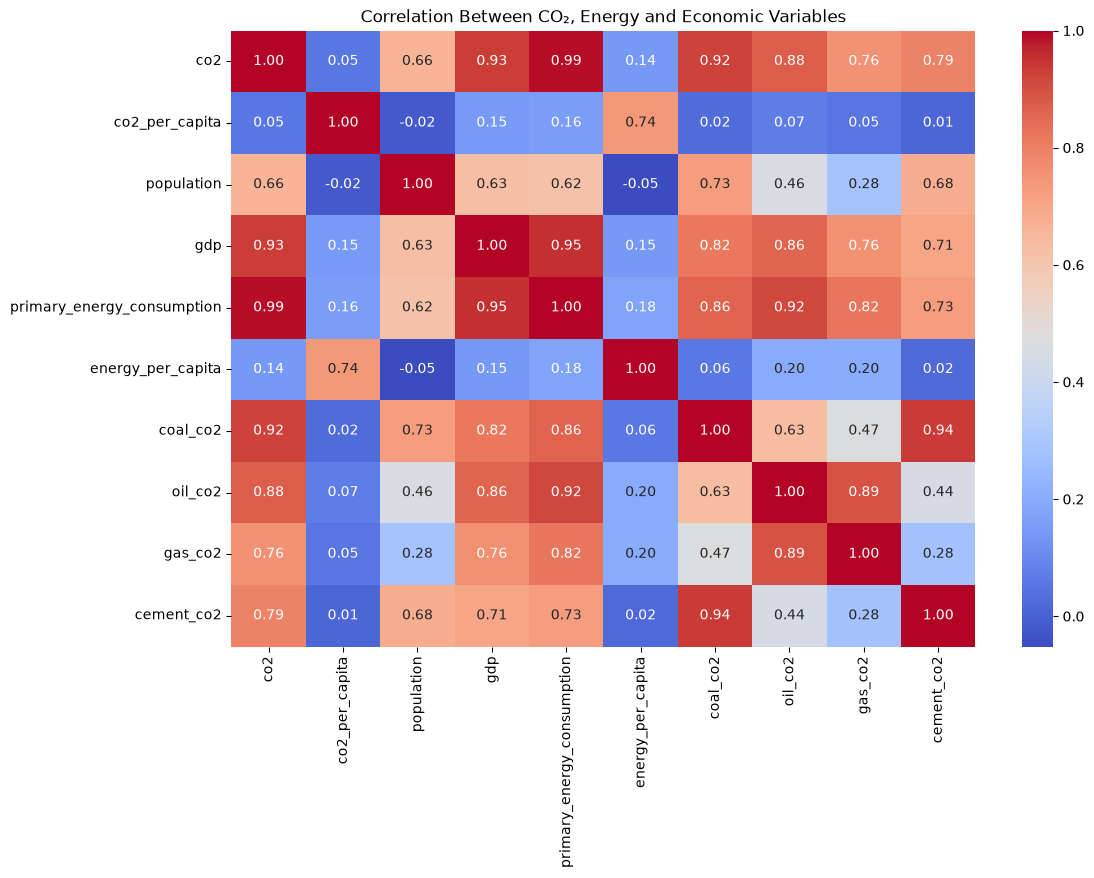

In [91]:
corr_cols = [
    'co2',
    'co2_per_capita',
    'population',
    'gdp',
    'primary_energy_consumption',
    'energy_per_capita',
    'coal_co2',
    'oil_co2',
    'gas_co2',
    'cement_co2'
]

plt.figure(figsize=(12, 8))
sns.heatmap(
    df_cleaned[corr_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Between CO₂, Energy and Economic Variables')
plt.show()

The heatmap shows that **CO₂ emissions are strongly correlated with primary energy consumption (0.99) and GDP (0.93)**, suggesting that higher economic activity and energy use are associated with higher emissions.

CO₂ also has strong relationships with **coal (0.92), oil (0.88), and gas emissions (0.76)**. These results support the importance of **economic activity, energy consumption, and historical emission patterns** when developing the forecasting model.

## 6. Feature Engineering

Feature engineering converts historical observations into predictors that represent information available at the time a forecast is made. Each engineered feature has a specific forecasting purpose.

### Why each feature is created

- **`gdp_per_capita_calc`** — captures economic activity relative to population size, making countries with different population sizes more comparable.
- **`energy_per_person_calc`** — captures energy use intensity per person and provides context for differences in emissions between countries.
- **`co2_lag1`, `co2_lag2`, `co2_lag3`** — capture short-term temporal dependence. Recent emissions are expected to contain information about the next year's emissions.
- **`co2_roll3`** — smooths short-term fluctuations and represents the recent three-year emissions level.
- **`co2_roll5`** — captures a longer five-year trend and reduces the influence of one unusual year.
- **`co2_growth_lag1`** — represents the previous growth rate, helping the model distinguish increasing, stable and declining emissions trajectories.
- **`energy_lag1`** — captures the previous year's energy demand, which can influence subsequent emissions.
- **`gdp_lag1`** — uses the previous year's economic activity so that the predictor reflects information available before the forecast year.
- **`population_lag1`** — captures the previous year's population level and its relationship with future emissions.
- **`target_co2`** — shifts CO₂ one year forward so the model learns the explicit task: **historical information → next year's CO₂ emissions**.

### Time-series leakage rule

All lagged and rolling features use only current or historical observations. The target is shifted forward by one year. Therefore, information from the future is not used to construct predictors for an earlier year.


### Feature engineering implementation

`build_model_frame()` implements the feature definitions above. The function first sorts each country's records chronologically, creates historical features, and then creates the next-year target. Rows where the next-year target does not exist are removed before supervised learning.


In [92]:
def build_model_frame(data):

    df = data.copy()

    # 1. Sort chronologically by country to guarantee clean time-shifts
    df = df.sort_values(['country', 'year']).reset_index(drop=True)

    # Group by country for shifting operations
    grouped = df.groupby('country')

    # 2. Shift the Target (Next Year's Total CO2)
    # This represents T+1. All features below will be relative to Year T.
    df['target_co2'] = grouped['co2'].shift(-1)

    # 3. Create Core Predictive Variables for Year T
    # We must ONLY use columns that exist in the original data at Year T.
    # Note: We do NOT include current-year 'co2' here to prevent target leakage.
    df['population_t'] = df['population']
    df['gdp_t'] = df['gdp']
    df['primary_energy_consumption_t'] = df['primary_energy_consumption']
    df['energy_per_capita_t'] = df['energy_per_capita']
    
    # Fuel breakdowns at Year T
    df['coal_co2_t'] = df['coal_co2']
    df['oil_co2_t'] = df['oil_co2']
    df['gas_co2_t'] = df['gas_co2']
    df['cement_co2_t'] = df['cement_co2']
    df['flaring_co2_t'] = df['flaring_co2']
    df['land_use_change_co2_t'] = df['land_use_change_co2']
    df['total_ghg_t'] = df['total_ghg']

    # 4. Derived Features for Year T
    df['gdp_per_capita_t'] = df['gdp_t'] / df['population_t']
    df['energy_per_person_t'] = df['primary_energy_consumption_t'] / df['population_t']

    # 5. Historical Lag Features (Relative to Year T)
    # These represent T-1, T-2, and T-3 respectively.
    df['co2_lag1'] = grouped['co2'].shift(1)
    df['co2_lag2'] = grouped['co2'].shift(2)
    df['co2_lag3'] = grouped['co2'].shift(3)

    # 6. Historical Rolling Averages (Excluding Year T)
    # Calculated over the past 3 and 5 years leading up to (and including) Year T
    df['co2_roll3'] = grouped['co2'].rolling(3).mean().reset_index(level=0, drop=True)
    df['co2_roll5'] = grouped['co2'].rolling(5).mean().reset_index(level=0, drop=True)

    # 7. Historical Growth Rate (Up to Year T)
    df['co2_growth_t'] = grouped['co2'].pct_change(fill_method=None)

    # 8. Clean up invalid/infinite calculations and return
    df = df.replace([np.inf, -np.inf], np.nan)

    return df


In [93]:
model_df = build_model_frame(df_cleaned)

print("Model frame shape:", model_df.shape)

model_df.head()

Model frame shape: (15000, 38)


,country,year,iso_code,gdp,population,co2,co2_per_capita,flaring_co2,cement_co2,coal_co2,oil_co2,gas_co2,land_use_change_co2,total_ghg,other_industry_co2,primary_energy_consumption,energy_per_capita,co2_including_luc,target_co2,population_t,gdp_t,primary_energy_consumption_t,energy_per_capita_t,coal_co2_t,oil_co2_t,gas_co2_t,cement_co2_t,flaring_co2_t,land_use_change_co2_t,total_ghg_t,gdp_per_capita_t,energy_per_person_t,co2_lag1,co2_lag2,co2_lag3,co2_roll3,co2_roll5,co2_growth_t
0,Afghanistan,1950,AFG,9.421400e+09,7776180.0,0.084,0.011,NaN,0.0,0.021,0.063,0.0,7.085,19.869,NaN,NaN,NaN,7.169,0.092,7776180.0,9.421400e+09,NaN,NaN,0.021,0.063,0.0,0.0,NaN,7.085,19.869,1211.571749,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1951,AFG,9.692280e+09,7879343.0,0.092,0.012,NaN,0.0,0.026,0.066,0.0,8.000,21.069,NaN,NaN,NaN,8.092,0.092,7879343.0,9.692280e+09,NaN,NaN,0.026,0.066,0.0,0.0,NaN,8.000,21.069,1230.087331,NaN,0.084,NaN,NaN,NaN,NaN,0.095238
2,Afghanistan,1952,AFG,1.001732e+10,7987784.0,0.092,0.011,NaN,0.0,0.032,0.060,0.0,8.914,22.094,NaN,NaN,NaN,9.005,0.106,7987784.0,1.001732e+10,NaN,NaN,0.032,0.060,0.0,0.0,NaN,8.914,22.094,1254.080606,NaN,0.092,0.084,NaN,0.089333,NaN,0.000000
3,Afghanistan,1953,AFG,1.063052e+10,8096703.0,0.106,0.013,NaN,0.0,0.038,0.068,0.0,9.964,23.256,NaN,NaN,NaN,10.070,0.106,8096703.0,1.063052e+10,NaN,NaN,0.038,0.068,0.0,0.0,NaN,9.964,23.256,1312.944293,NaN,0.092,0.092,0.084,0.096667,NaN,0.152174
4,Afghanistan,1954,AFG,1.086636e+10,8207954.0,0.106,0.013,NaN,0.0,0.043,0.064,0.0,10.821,24.251,NaN,NaN,NaN,10.928,0.154,8207954.0,1.086636e+10,NaN,NaN,0.043,0.064,0.0,0.0,NaN,10.821,24.251,1323.881688,NaN,0.106,0.092,0.092,0.101333,0.096,0.000000


Our processed data has 15000 rows and 28 columns for modelling.

In [94]:
# checking the target
model_df[
    [
        'country',
        'year',
        'co2',
        'co2_lag1',
        'co2_lag2',
        'co2_roll3',
        'target_co2'
    ]
].tail(20)

,country,year,co2,co2_lag1,co2_lag2,co2_roll3,target_co2
14980,Zimbabwe,2005,10.698,9.429,10.610,10.245667,10.365
14981,Zimbabwe,2006,10.365,10.698,9.429,10.164000,9.835
14982,Zimbabwe,2007,9.835,10.365,10.698,10.299333,7.720
14983,Zimbabwe,2008,7.720,9.835,10.365,9.306667,8.250
14984,Zimbabwe,2009,8.250,7.720,9.835,8.601667,8.754
14985,Zimbabwe,2010,8.754,8.250,7.720,8.241333,10.363
14986,Zimbabwe,2011,10.363,8.754,8.250,9.122333,11.257
14987,Zimbabwe,2012,11.257,10.363,8.754,10.124667,11.671
14988,Zimbabwe,2013,11.671,11.257,10.363,11.097000,11.946
14989,Zimbabwe,2014,11.946,11.671,11.257,11.624667,12.017


`target_co2` value for 2024 does not exist and will need to be handled next.

In [95]:
# Removing target that does not exist (i.e., the last year for each country)
model_df = model_df[
    model_df['target_co2'].notna()
].copy()

In [96]:
# Choosing feature columns for the model
feature_cols = [
    'year',
    'population',
    'gdp',

    'co2_lag1',
    'co2_lag2',
    'co2_lag3',
    'co2_roll3',
    'co2_roll5',

    'gdp_lag1',
    'population_lag1',

    'primary_energy_consumption',
    'energy_lag1',
    'energy_per_capita',
    'energy_per_gdp',

    'coal_co2',
    'oil_co2',
    'gas_co2',
    'cement_co2',
    'flaring_co2',
    'land_use_change_co2',

    'total_ghg',
    'total_ghg_excluding_lucf',

    'gdp_per_capita_calc',
    'energy_per_person_calc'
]

feature_cols = [
    col for col in feature_cols
    if col in model_df.columns
]

print("Number of features:", len(feature_cols))
print(feature_cols)

Number of features: 17
['year', 'population', 'gdp', 'co2_lag1', 'co2_lag2', 'co2_lag3', 'co2_roll3', 'co2_roll5', 'primary_energy_consumption', 'energy_per_capita', 'coal_co2', 'oil_co2', 'gas_co2', 'cement_co2', 'flaring_co2', 'land_use_change_co2', 'total_ghg']


In [97]:
# Adding countries
feature_cols = ['country'] + feature_cols

categorical_features = ['country']

numeric_features = [
    col for col in feature_cols
    if col not in categorical_features
]

Separated categorical features and numeric features 

In [98]:
# Handling missing values in the features
numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            'imputer',
            SimpleImputer(strategy='most_frequent')
        ),
        (
            'onehot',
            OneHotEncoder(
                handle_unknown='ignore'
            )
        )
    ]
)

The `categorical_transformer` is there as a fail safe for deployment. 

## 7. Modelling

The modelling process follows a controlled sequence: **baseline → candidate models → model comparison → hyperparameter tuning → final model evaluation**.


### 7.1 Baseline model — naive persistence

The naive persistence forecast uses the most recent observed CO₂ value as the prediction for the next year. This is an appropriate time-series benchmark because annual CO₂ emissions are strongly persistent. A machine-learning model should demonstrate value beyond simply carrying the previous year's value forward.


### 7.2 Chronological data split

- **Training:** years up to 2013
- **Validation:** 2014–2018
- **Test:** 2019–2023
- **Forecast input:** 2024 observations for 2025 forecasting

The validation period is used for model comparison and tuning decisions. The test period is kept as an unseen final assessment.


In [99]:
# Chronological train / validation / test split
train_df = model_df[
    model_df['year'] <= 2013
].copy()

valid_df = model_df[
    (model_df['year'] >= 2014) &
    (model_df['year'] <= 2018)
].copy()

test_df = model_df[
    (model_df['year'] >= 2019) &
    (model_df['year'] <= 2023)
].copy()

# 2024 will be used later for forecasting 2025
# Shape of train dataset
print(
    "Train:",
    train_df.shape
)

# Shape of validation dataset
print(
    "Validation:",
    valid_df.shape
)

# Shape of test dataset
print(
    "Test:",
    test_df.shape
)

Train: (12560, 38)
Validation: (1000, 38)
Test: (1000, 38)


In [100]:
# Splitting the data into training, validation, and test sets
X_train = train_df[feature_cols]
y_train = train_df['target_co2']

X_valid = valid_df[feature_cols]
y_valid = valid_df['target_co2']

X_test = test_df[feature_cols]
y_test = test_df['target_co2']

# Checking the shape of the training, validation, and test sets
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_valid:", X_valid.shape)
print("y_valid:", y_valid.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (12560, 18)
y_train: (12560,)
X_valid: (1000, 18)
y_valid: (1000,)
X_test: (1000, 18)
y_test: (1000,)


In [101]:
# Model data preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            numeric_transformer,
            numeric_features
        ),
        (
            'cat',
            categorical_transformer,
            categorical_features
        )
    ]
)

Missing values handled here.

In [102]:
# Baseline model: Naive model
baseline_valid_pred = valid_df['co2']

baseline_valid_mae = mean_absolute_error(
    y_valid,# y_valid = valid_df['target_co2']
    baseline_valid_pred
)

baseline_valid_rmse = np.sqrt(
    mean_squared_error(
        y_valid,
        baseline_valid_pred
    )
)

baseline_valid_r2 = r2_score(
    y_valid,
    baseline_valid_pred
)

print("Naive Baseline - Validation")
print("MAE :", round(baseline_valid_mae, 3))
print("RMSE:", round(baseline_valid_rmse, 3))
print("R²  :", round(baseline_valid_r2, 3))

Naive Baseline - Validation
MAE : 5.469
RMSE: 23.611
R²  : 0.999


The very high R² values should be interpreted carefully. High R² alone does **not** prove overfitting. In annual CO₂ forecasting, strong temporal persistence can naturally produce high R². The validation/test comparison and error metrics are therefore used together to judge generalisation.


### 7.3 Candidate models

The candidate models represent increasing levels of complexity:

- **Ridge Regression:** interpretable linear baseline that handles correlated predictors through regularisation.
- **Random Forest:** nonlinear ensemble capable of learning interactions and nonlinear relationships.
- **Extra Trees:** highly randomised tree ensemble that can capture nonlinear patterns.
- **HistGradientBoosting:** sequential boosting model designed to learn complex nonlinear relationships.

The models are fitted through preprocessing pipelines so missing-value imputation and categorical encoding are learned from the training data only.


### 7.4 Initial model comparison

The initial candidate models are compared on the same validation period. The validation set—not the test set—is used to identify the most promising approach.


In [103]:
# The test set is intentionally not used for model selection.
# Final test predictions are generated in Section 9 after tuning and validation-based model selection.


### 7.5 Ridge Regression — initial fit

Ridge provides a regularised linear benchmark and is useful for determining whether the relationships in the engineered features are approximately linear.


In [104]:
# Fit Ridge on the training period and evaluate on validation data only
ridge_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', Ridge(alpha=10.0))
    ]
)

ridge_model.fit(X_train, y_train)
ridge_valid_pred = ridge_model.predict(X_valid)

ridge_valid_metrics = {
    'MAE': mean_absolute_error(y_valid, ridge_valid_pred),
    'RMSE': np.sqrt(mean_squared_error(y_valid, ridge_valid_pred)),
    'R2': r2_score(y_valid, ridge_valid_pred)
}

print('Ridge Regression - Validation:', ridge_valid_metrics)


Ridge Regression - Validation: {'MAE': 6.859742660294415, 'RMSE': np.float64(32.35876905390752), 'R2': 0.9985021174527339}


### 7.6 Random Forest — initial fit

Random Forest is evaluated to determine whether nonlinear relationships and interactions improve on the linear model and naive persistence benchmark.


In [105]:
# Fit Random Forest on the training period and evaluate on validation data only
random_forest_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(
            n_estimators=300,
            max_depth=12,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

random_forest_model.fit(X_train, y_train)
random_forest_valid_pred = random_forest_model.predict(X_valid)

print('Random Forest - Validation')
print('MAE :', mean_absolute_error(y_valid, random_forest_valid_pred))
print('RMSE:', np.sqrt(mean_squared_error(y_valid, random_forest_valid_pred)))
print('R2  :', r2_score(y_valid, random_forest_valid_pred))


Random Forest - Validation
MAE : 9.11868913189133
RMSE: 47.381009495185694
R2  : 0.9967885409046829


### 7.7 Extra Trees — initial fit

Extra Trees provides a second nonlinear tree ensemble and tests whether greater randomisation improves generalisation.


In [106]:
# Fit Extra Trees on the training period and evaluate on validation data only
extra_trees_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', ExtraTreesRegressor(
            n_estimators=300,
            max_depth=12,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

extra_trees_model.fit(X_train, y_train)
extra_trees_valid_pred = extra_trees_model.predict(X_valid)

print('Extra Trees - Validation')
print('MAE :', mean_absolute_error(y_valid, extra_trees_valid_pred))
print('RMSE:', np.sqrt(mean_squared_error(y_valid, extra_trees_valid_pred)))
print('R2  :', r2_score(y_valid, extra_trees_valid_pred))


Extra Trees - Validation
MAE : 7.971928242208692
RMSE: 36.090950194909205
R2  : 0.9981366672889181


### 7.8 HistGradientBoosting — initial fit

HistGradientBoosting tests a boosting approach that can model complex nonlinear relationships. Its performance is compared with the simpler models before any final selection.


In [107]:
# Use dense one-hot output because HistGradientBoosting does not accept sparse matrices
hgb_preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        (
            'cat',
            Pipeline(
                steps=[
                    ('imputer', SimpleImputer(strategy='most_frequent')),
                    ('onehot', OneHotEncoder(
                        handle_unknown='ignore',
                        sparse_output=False
                    ))
                ]
            ),
            categorical_features
        )
    ]
)

hist_gradient_boosting_model = Pipeline(
    steps=[
        ('preprocessor', hgb_preprocessor),
        ('model', HistGradientBoostingRegressor(
            max_iter=300,
            learning_rate=0.05,
            max_leaf_nodes=31,
            l2_regularization=1.0,
            random_state=42
        ))
    ]
)

hist_gradient_boosting_model.fit(X_train, y_train)
hgb_valid_pred = hist_gradient_boosting_model.predict(X_valid)
hgb_test_pred = hist_gradient_boosting_model.predict(X_test)

print('HistGradientBoosting - Validation')
print('MAE :', mean_absolute_error(y_valid, hgb_valid_pred))
print('RMSE:', np.sqrt(mean_squared_error(y_valid, hgb_valid_pred)))
print('R2  :', r2_score(y_valid, hgb_valid_pred))


HistGradientBoosting - Validation
MAE : 25.343226160341178
RMSE: 202.6632764843873
R2  : 0.9412451265723629


### 7.9 Model comparison

The comparison table reports MAE, RMSE and R² on the same validation and test periods for transparency. **Only validation performance should guide model/tuning decisions; test performance is reported as the final hold-out result.**


In [108]:
# Compare candidate models using validation data only
# The test period is reserved for Section 9 final evaluation.
comparison = pd.DataFrame([
    {'Model': 'Naive persistence', 'Validation MAE': baseline_valid_mae, 'Validation RMSE': baseline_valid_rmse, 'Validation R2': baseline_valid_r2},
    {'Model': 'Ridge', 'Validation MAE': ridge_valid_metrics['MAE'], 'Validation RMSE': ridge_valid_metrics['RMSE'], 'Validation R2': ridge_valid_metrics['R2']},
    {'Model': 'Random Forest', 'Validation MAE': mean_absolute_error(y_valid, random_forest_valid_pred), 'Validation RMSE': np.sqrt(mean_squared_error(y_valid, random_forest_valid_pred)), 'Validation R2': r2_score(y_valid, random_forest_valid_pred)},
    {'Model': 'Extra Trees', 'Validation MAE': mean_absolute_error(y_valid, extra_trees_valid_pred), 'Validation RMSE': np.sqrt(mean_squared_error(y_valid, extra_trees_valid_pred)), 'Validation R2': r2_score(y_valid, extra_trees_valid_pred)},
    {'Model': 'HistGradientBoosting', 'Validation MAE': mean_absolute_error(y_valid, hgb_valid_pred), 'Validation RMSE': np.sqrt(mean_squared_error(y_valid, hgb_valid_pred)), 'Validation R2': r2_score(y_valid, hgb_valid_pred)}
]).sort_values('Validation RMSE')

comparison.round(3)


,Model,Validation MAE,Validation RMSE,Validation R2
0,Naive persistence,5.469,23.611,0.999
1,Ridge,6.860,32.359,0.999
3,Extra Trees,7.972,36.091,0.998
2,Random Forest,9.119,47.381,0.997
4,HistGradientBoosting,25.343,202.663,0.941


## 8. Hyperparameter Tuning

Hyperparameter tuning is performed **after the initial model comparison** so that tuning effort is focused on promising models. The tuning process uses only the training data and temporal cross-validation. The validation period remains separate for model selection.

### Why tune?

Hyperparameters control model complexity and regularisation. Tuning can improve generalisation by finding settings that balance underfitting and overfitting rather than relying on arbitrary defaults.


In [109]:
# Hyperparameter tuning using temporal cross-validation
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV

# Sort training observations by year so CV respects temporal order
tuning_train = train_df.sort_values(['year', 'country']).reset_index(drop=True)
X_tune = tuning_train[feature_cols]
y_tune = tuning_train['target_co2']

# Temporal cross-validation: each validation fold occurs after its training fold
cv = TimeSeriesSplit(n_splits=4)

# Ridge tuning
ridge_search = RandomizedSearchCV(
    estimator=Pipeline([
        ('preprocessor', preprocessor),
        ('model', Ridge())
    ]),
    param_distributions={
        'model__alpha': [0.01, 0.1, 1, 5, 10, 25, 50, 100]
    },
    n_iter=8,
    scoring='neg_root_mean_squared_error',
    cv=cv,
    random_state=42,
    n_jobs=-1
)

ridge_search.fit(X_tune, y_tune)
print('Best Ridge parameters:', ridge_search.best_params_)
print('Best Ridge CV RMSE:', -ridge_search.best_score_)

# Random Forest tuning
rf_search = RandomizedSearchCV(
    estimator=Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(random_state=42, n_jobs=-1))
    ]),
    param_distributions={
        'model__n_estimators': [200, 300, 500],
        'model__max_depth': [None, 8, 12, 16],
        'model__min_samples_leaf': [1, 2, 4],
        'model__min_samples_split': [2, 5, 10],
        'model__max_features': ['sqrt', 'log2', 1.0]
    },
    n_iter=12,
    scoring='neg_root_mean_squared_error',
    cv=cv,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_tune, y_tune)
print('Best Random Forest parameters:', rf_search.best_params_)
print('Best Random Forest CV RMSE:', -rf_search.best_score_)

Best Ridge parameters: {'model__alpha': 5}
Best Ridge CV RMSE: 21.941333753589802
Best Random Forest parameters: {'model__n_estimators': 500, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 1.0, 'model__max_depth': 8}
Best Random Forest CV RMSE: 101.01865053531192


### 8.1 Tuned-model validation comparison

The tuned models are now evaluated on the **validation years (2014–2018)**. This step selects the model configuration without using the final test period.


In [110]:
# Replace the initial models with their tuned versions for validation comparison
tuned_ridge_model = ridge_search.best_estimator_
tuned_rf_model = rf_search.best_estimator_

tuned_ridge_valid_pred = tuned_ridge_model.predict(X_valid)
tuned_rf_valid_pred = tuned_rf_model.predict(X_valid)

tuned_comparison = pd.DataFrame([
    {
        'Model': 'Naive persistence',
        'Validation MAE': mean_absolute_error(y_valid, baseline_valid_pred),
        'Validation RMSE': np.sqrt(mean_squared_error(y_valid, baseline_valid_pred)),
        'Validation R2': r2_score(y_valid, baseline_valid_pred)
    },
    {
        'Model': 'Tuned Ridge',
        'Validation MAE': mean_absolute_error(y_valid, tuned_ridge_valid_pred),
        'Validation RMSE': np.sqrt(mean_squared_error(y_valid, tuned_ridge_valid_pred)),
        'Validation R2': r2_score(y_valid, tuned_ridge_valid_pred)
    },
    {
        'Model': 'Tuned Random Forest',
        'Validation MAE': mean_absolute_error(y_valid, tuned_rf_valid_pred),
        'Validation RMSE': np.sqrt(mean_squared_error(y_valid, tuned_rf_valid_pred)),
        'Validation R2': r2_score(y_valid, tuned_rf_valid_pred)
    },
    {
        'Model': 'Extra Trees',
        'Validation MAE': mean_absolute_error(y_valid, extra_trees_valid_pred),
        'Validation RMSE': np.sqrt(mean_squared_error(y_valid, extra_trees_valid_pred)),
        'Validation R2': r2_score(y_valid, extra_trees_valid_pred)
    },
    {
        'Model': 'HistGradientBoosting',
        'Validation MAE': mean_absolute_error(y_valid, hgb_valid_pred),
        'Validation RMSE': np.sqrt(mean_squared_error(y_valid, hgb_valid_pred)),
        'Validation R2': r2_score(y_valid, hgb_valid_pred)
    }
]).sort_values('Validation RMSE')

tuned_comparison.round(3)

,Model,Validation MAE,Validation RMSE,Validation R2
0,Naive persistence,5.469,23.611,0.999
1,Tuned Ridge,6.918,31.343,0.999
3,Extra Trees,7.972,36.091,0.998
2,Tuned Random Forest,8.619,36.445,0.998
4,HistGradientBoosting,25.343,202.663,0.941


## 9. Final Model Evaluation

Only after the validation comparison and hyperparameter tuning is the final model assessed on the untouched **2019–2023 test period**. This gives a more honest estimate of performance on unseen future years.

### Evaluation metrics

- **MAE:** average absolute forecasting error; lower is better.
- **RMSE:** penalises large errors more strongly; lower is better.
- **R²:** proportion of variance explained; higher is better, but it must be interpreted alongside MAE and RMSE.


In [111]:
# Final hold-out test predictions are created only after tuning/model selection
baseline_test_pred = test_df['co2']
tuned_ridge_test_pred = tuned_ridge_model.predict(X_test)
tuned_rf_test_pred = tuned_rf_model.predict(X_test)
extra_trees_test_pred = extra_trees_model.predict(X_test)
hgb_test_pred = hist_gradient_boosting_model.predict(X_test)

final_evaluation = pd.DataFrame([
    {'Model': 'Naive persistence', 'Test MAE': mean_absolute_error(y_test, baseline_test_pred), 'Test RMSE': np.sqrt(mean_squared_error(y_test, baseline_test_pred)), 'Test R2': r2_score(y_test, baseline_test_pred)},
    {'Model': 'Tuned Ridge', 'Test MAE': mean_absolute_error(y_test, tuned_ridge_test_pred), 'Test RMSE': np.sqrt(mean_squared_error(y_test, tuned_ridge_test_pred)), 'Test R2': r2_score(y_test, tuned_ridge_test_pred)},
    {'Model': 'Tuned Random Forest', 'Test MAE': mean_absolute_error(y_test, tuned_rf_test_pred), 'Test RMSE': np.sqrt(mean_squared_error(y_test, tuned_rf_test_pred)), 'Test R2': r2_score(y_test, tuned_rf_test_pred)},
    {'Model': 'Extra Trees', 'Test MAE': mean_absolute_error(y_test, extra_trees_test_pred), 'Test RMSE': np.sqrt(mean_squared_error(y_test, extra_trees_test_pred)), 'Test R2': r2_score(y_test, extra_trees_test_pred)},
    {'Model': 'HistGradientBoosting', 'Test MAE': mean_absolute_error(y_test, hgb_test_pred), 'Test RMSE': np.sqrt(mean_squared_error(y_test, hgb_test_pred)), 'Test R2': r2_score(y_test, hgb_test_pred)}
]).sort_values('Test RMSE')

final_evaluation.round(3)


,Model,Test MAE,Test RMSE,Test R2
1,Tuned Ridge,8.655,31.883,0.999
0,Naive persistence,7.859,36.559,0.998
3,Extra Trees,19.576,151.926,0.973
2,Tuned Random Forest,21.524,164.585,0.968
4,HistGradientBoosting,39.456,325.848,0.876


### 9.1 Final model selection

The final model should be selected using **validation performance first**, with the test results used only to report generalisation. If the naive persistence model remains the strongest approach, it should be retained as the operational benchmark rather than forcing a more complex machine-learning model. This is an important result in time-series forecasting: complexity is only useful when it improves out-of-sample accuracy.


In [112]:
# Select the best model by validation RMSE
best_model_name = tuned_comparison.iloc[0]['Model']
print('Best model based on validation RMSE:', best_model_name)

# Display the validation ranking
tuned_comparison.round(3)

Best model based on validation RMSE: Naive persistence


,Model,Validation MAE,Validation RMSE,Validation R2
0,Naive persistence,5.469,23.611,0.999
1,Tuned Ridge,6.918,31.343,0.999
3,Extra Trees,7.972,36.091,0.998
2,Tuned Random Forest,8.619,36.445,0.998
4,HistGradientBoosting,25.343,202.663,0.941


## 9.2 Overfitting and Generalisation Check

Overfitting occurs when a model learns patterns that work very well on training data but do not generalise to unseen future years. We compare training, validation and test performance. A large increase in error from training to future periods is a warning sign of overfitting or instability. Because CO₂ emissions are highly persistent, a high R² alone is not enough to establish good forecasting performance.

### What this output tells us

This table compares training, validation and test performance to check whether the models generalise to unseen future years. A large increase in RMSE from training to test indicates possible overfitting or instability. The **Test/Train RMSE Ratio** helps identify models whose errors grow substantially outside the training period.

For this forecasting problem, we should prefer a model that remains stable on future years rather than a model that only performs extremely well on historical training data.


In [113]:
# Overfitting / generalisation check
model_predictions = {
    'Ridge': (ridge_model, ridge_valid_pred, tuned_ridge_test_pred),
    'Random Forest': (random_forest_model, random_forest_valid_pred, tuned_rf_test_pred),
    'Extra Trees': (extra_trees_model, extra_trees_valid_pred, extra_trees_test_pred),
    'HistGradientBoosting': (hist_gradient_boosting_model, hgb_valid_pred, hgb_test_pred)
}
rows = []
for name, (model, valid_pred, test_pred) in model_predictions.items():
    train_pred = model.predict(X_train)
    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    rows.append({
        'Model': name, 'Train MAE': mean_absolute_error(y_train, train_pred),
        'Validation MAE': mean_absolute_error(y_valid, valid_pred), 'Test MAE': mean_absolute_error(y_test, test_pred),
        'Train RMSE': train_rmse, 'Validation RMSE': np.sqrt(mean_squared_error(y_valid, valid_pred)),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, test_pred)),
        'Train R2': r2_score(y_train, train_pred), 'Validation R2': r2_score(y_valid, valid_pred),
        'Test R2': r2_score(y_test, test_pred),
        'Test/Train RMSE Ratio': np.nan if train_rmse == 0 else np.sqrt(mean_squared_error(y_test, test_pred))/train_rmse
    })
overfitting_check = pd.DataFrame(rows).sort_values('Test/Train RMSE Ratio', ascending=False)
overfitting_check.round(3)

,Model,Train MAE,Validation MAE,Test MAE,Train RMSE,Validation RMSE,Test RMSE,Train R2,Validation R2,Test R2,Test/Train RMSE Ratio
2,Extra Trees,2.522,7.972,19.576,8.366,36.091,151.926,1.000,0.998,0.973,18.160
1,Random Forest,2.652,9.119,21.524,17.176,47.381,164.585,0.999,0.997,0.968,9.583
3,HistGradientBoosting,6.633,25.343,39.456,49.528,202.663,325.848,0.989,0.941,0.876,6.579
0,Ridge,4.329,6.860,8.655,18.552,32.359,31.883,0.998,0.999,0.999,1.719


### Interpretation of the overfitting check

The existing results show that the more complex tree models have much larger test errors than their validation errors, while Ridge is more stable. This suggests weaker generalisation for the tree models. The naive persistence forecast is also a very strong benchmark, so extra model complexity is justified only when it improves out-of-sample forecasting accuracy.

## 9.3 Error Analysis

Error analysis identifies where and when the model makes mistakes. A good average score can hide very large errors for individual countries or years, so we inspect residuals, absolute errors and percentage errors on the untouched test period.

### How to read the error-analysis output

The table below identifies individual country-year forecasts where the tuned Ridge model makes the largest mistakes. **Error** is actual CO₂ minus predicted CO₂, while **Absolute Error** measures the size of the mistake regardless of direction. **Percentage Error** makes errors easier to compare across countries with very different emissions levels.

This helps us identify countries or years that deserve further investigation rather than relying only on one overall accuracy score.


In [114]:
# Detailed error analysis on the test period using the tuned Ridge model
error_analysis = test_df[['country', 'year', 'target_co2']].copy()
error_analysis['Actual CO2'] = y_test.values
error_analysis['Prediction'] = tuned_ridge_test_pred
error_analysis['Error'] = error_analysis['Actual CO2'] - error_analysis['Prediction']
error_analysis['Absolute Error'] = error_analysis['Error'].abs()
error_analysis['Percentage Error'] = np.where(
    error_analysis['Actual CO2'].abs() > 1e-9,
    error_analysis['Absolute Error'] / error_analysis['Actual CO2'].abs() * 100, np.nan
)
print('Largest Ridge forecasting errors:')
error_analysis.sort_values('Absolute Error', ascending=False).head(15).round(3)

Largest Ridge forecasting errors:


,country,year,target_co2,Actual CO2,Prediction,Error,Absolute Error,Percentage Error
14394,United States,2019,4689.954,4689.954,5231.026,-541.072,541.072,11.537
2919,China,2019,10896.521,10896.521,11270.650,-374.129,374.129,3.433
14395,United States,2020,5020.111,5020.111,4667.559,352.552,352.552,7.023
6369,India,2019,2422.732,2422.732,2769.081,-346.349,346.349,14.296
2920,China,2020,11284.401,11284.401,11465.913,-181.512,181.512,1.609
2923,China,2023,12289.037,12289.037,12467.459,-178.422,178.422,1.452
14398,United States,2023,4904.120,4904.120,4746.669,157.451,157.451,3.211
2921,China,2021,11711.808,11711.808,11864.599,-152.791,152.791,1.305
14397,United States,2022,4918.407,4918.407,5067.888,-149.481,149.481,3.039
6370,India,2020,2675.778,2675.778,2555.449,120.329,120.329,4.497


### How to read the country-level error output

This table aggregates forecasting errors by country. It helps identify countries where the model is consistently less accurate, rather than focusing only on one unusual year.

A high **Mean Absolute Error** indicates that forecasts are, on average, farther from actual emissions for that country. These results can guide data-quality checks and future feature engineering.


In [115]:
# Error summary by country
country_error_summary = (
    error_analysis.groupby('country')
    .agg(Mean_Absolute_Error=('Absolute Error','mean'), Max_Absolute_Error=('Absolute Error','max'),
         Mean_Percentage_Error=('Percentage Error','mean'), Observations=('Absolute Error','size'))
    .sort_values('Mean_Absolute_Error', ascending=False)
)
country_error_summary.head(15).round(3)

,Mean_Absolute_Error,Max_Absolute_Error,Mean_Percentage_Error,Observations
country,,,,
United States,249.162,541.072,5.141,5
China,198.631,374.129,1.734,5
India,106.517,346.349,4.188,5
Indonesia,59.517,107.197,8.700,5
Brazil,55.286,89.741,11.738,5
Russia,50.737,77.799,2.979,5
Japan,38.800,74.908,3.807,5
Germany,38.651,73.390,6.192,5
Saudi Arabia,31.276,65.561,4.671,5


### What does model performance mean to the end user?

For a policy maker, environmental planner or emissions-monitoring team, model performance answers: **how much confidence should we place in the forecast?** MAE describes the average size of the forecasting mistake, RMSE highlights large mistakes, and R² describes explained variation.

The current test results show naive persistence with MAE ≈ 7.86 and RMSE ≈ 36.56, while Ridge has MAE ≈ 8.44 and RMSE ≈ 31.39. Ridge therefore does not reduce the average absolute error compared with persistence, but it does reduce the influence of larger errors. The simple persistence forecast remains a very strong practical benchmark.

**End-user message:** forecasts should be treated as planning estimates, not exact future values. Countries with unusually large errors should receive additional review before forecasts are used for high-stakes decisions.

## 9.4 Which Features Are Driving the Prediction?

Feature importance shows which variables the model relies on for prediction. Importance indicates predictive contribution, not causation, especially because lagged CO₂, GDP, energy use and fuel-specific emissions are correlated. We use permutation importance on the validation set for the tuned Random Forest.

### How to read the feature-importance output

Permutation importance measures how much validation performance deteriorates when one feature is randomly shuffled. A larger positive value means that the model relied more heavily on that feature for prediction.

This is **predictive importance, not causation**. Highly related variables such as historical CO₂, energy consumption and GDP may share predictive information, so an important feature should not automatically be interpreted as the reason emissions increase or decrease.


In [116]:
# Permutation feature importance for the tuned Random Forest
from sklearn.inspection import permutation_importance
rf_perm = permutation_importance(
    tuned_rf_model, X_valid, y_valid, scoring='neg_root_mean_squared_error',
    n_repeats=10, random_state=42, n_jobs=-1
)
feature_importance = pd.DataFrame({
    'Feature': X_valid.columns,
    'Importance Mean': rf_perm.importances_mean,
    'Importance Std': rf_perm.importances_std
}).sort_values('Importance Mean', ascending=False)
print('Top features driving the Random Forest prediction:')
feature_importance.head(15).round(5)

Top features driving the Random Forest prediction:


,Feature,Importance Mean,Importance Std
4,co2_lag1,356.37757,11.50263
7,co2_roll3,262.05411,6.17698
17,total_ghg,216.75746,6.17980
8,co2_roll5,94.73708,2.45192
14,cement_co2,64.04841,1.58603
11,coal_co2,56.20666,2.36852
5,co2_lag2,47.38824,1.20211
3,gdp,39.25200,0.89683
2,population,28.86382,0.73974
6,co2_lag3,27.50865,0.68138


### Interpreting the feature-importance chart

The chart ranks the features that contribute most to the Random Forest's validation predictions. Features near the top have the greatest measured effect on validation performance when their information is disrupted.

The chart should be interpreted together with the future-feature availability table that follows, because a feature can be highly predictive historically but difficult to obtain for future forecasting.


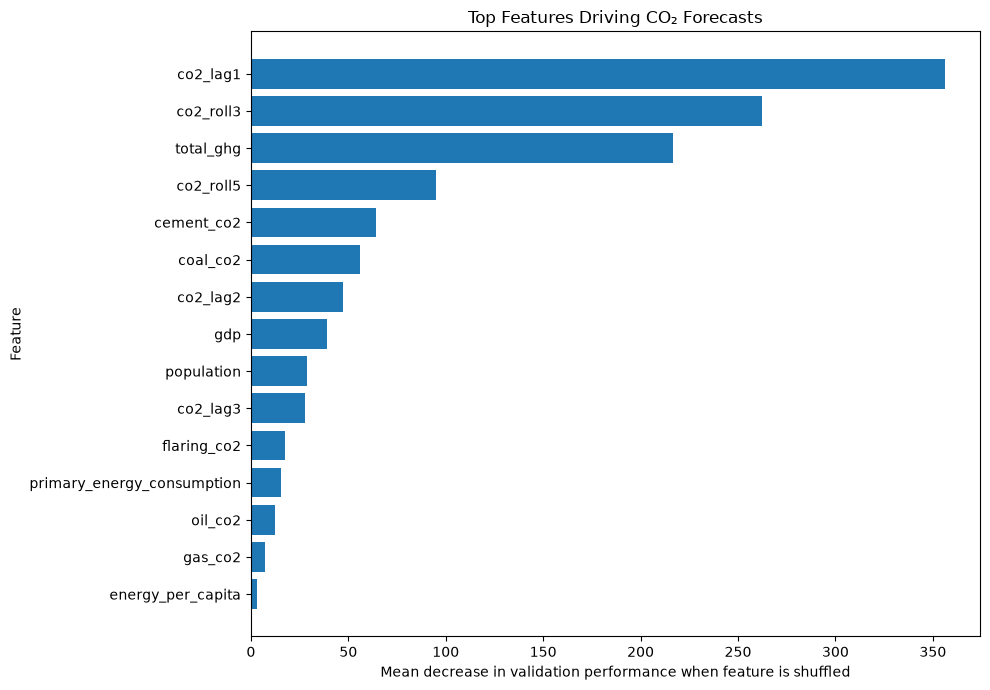

In [117]:
# Plot top predictive features
top_features = feature_importance.head(15).sort_values('Importance Mean')
plt.figure(figsize=(10,7))
plt.barh(top_features['Feature'], top_features['Importance Mean'])
plt.xlabel('Mean decrease in validation performance when feature is shuffled')
plt.ylabel('Feature')
plt.title('Top Features Driving CO₂ Forecasts')
plt.tight_layout()
plt.show()

### Do the important features make sense for the future?

**Strong future-ready predictors:**
- `co2_lag1`, `co2_lag2`, `co2_lag3`: historical emissions are known and capture emissions momentum.
- `co2_roll3`, `co2_roll5`: summarise recent historical trends.
- `gdp_lag1`, `population_lag1`, `energy_lag1`: use information from the previous year and therefore avoid needing future values.
- `country`: captures persistent country differences, but is not a causal driver.

**Predictors requiring caution:** current-year GDP, population, energy consumption and fuel-specific emissions can be used for a one-year-ahead forecast when the latest observations are available. For forecasts several years ahead, these variables will also need their own forecasts. Otherwise, the model may look accurate in historical testing but be difficult to operate in the real future.

Aggregate variables such as `total_ghg` can be highly predictive, but their importance should not be interpreted as independent causation because they overlap conceptually with emissions measures.

### Why we need a future-feature availability table

A model can perform well during historical testing but still be difficult to use in the real world if its most important inputs are not known when a future forecast is required.

The table below therefore distinguishes between features that are already known at forecast time, features derived from historical observations, and features that would themselves need to be forecast for longer forecasting horizons.


In [118]:
# Future-feature availability table
def future_feature_status(feature):
    if feature == 'country':
        return (
            'Known',
            'Yes',
            'Yes',
            'Country identity is known for future forecasts.',
            'Keep'
        )
    if feature == 'year':
        return (
            'Known',
            'Yes',
            'Yes',
            'Forecast year is known in advance.',
            'Keep'
        )
    if feature in {'co2_lag1', 'co2_lag2', 'co2_lag3', 'co2_roll3', 'co2_roll5',
                   'gdp_lag1', 'population_lag1', 'energy_lag1'}:
        return (
            'Historical / lagged',
            'Yes',
            'Conditional',
            'Uses information already observed before the forecast year; for multi-year recursive forecasts, new lag values depend on earlier forecasts.',
            'Keep'
        )
    if feature in {
        'population', 'gdp', 'primary_energy_consumption', 'energy_per_capita',
        'energy_per_gdp', 'coal_co2', 'oil_co2', 'gas_co2', 'cement_co2',
        'flaring_co2', 'land_use_change_co2', 'total_ghg',
        'total_ghg_excluding_lucf', 'gdp_per_capita_calc',
        'energy_per_person_calc'
    }:
        return (
            'Current-year value',
            'Yes, if latest data exist',
            'No — forecast required',
            'The future value is not known for longer horizons and would need a separate forecast or scenario assumption.',
            'Use with caution'
        )
    return (
        'Check',
        'Depends on data availability',
        'Depends on data availability',
        'Confirm that the feature will be available without using future information.',
        'Review'
    )

audit_rows = []
for feature in feature_cols:
    status = future_feature_status(feature)
    audit_rows.append({
        'Feature': feature,
        'Feature type': status[0],
        'Available for 1-year forecast?': status[1],
        'Available for multi-year forecast?': status[2],
        'Future-use consideration': status[3],
        'Recommendation': status[4]
    })

future_feature_audit = pd.DataFrame(audit_rows)
future_feature_audit


,Feature,Feature type,Available for 1-year forecast?,Available for multi-year forecast?,Future-use consideration,Recommendation
0,country,Known,Yes,Yes,Country identity is known for future forecasts.,Keep
1,year,Known,Yes,Yes,Forecast year is known in advance.,Keep
2,population,Current-year value,"Yes, if latest data exist",No — forecast required,The future value is not known for longer horiz...,Use with caution
3,gdp,Current-year value,"Yes, if latest data exist",No — forecast required,The future value is not known for longer horiz...,Use with caution
4,co2_lag1,Historical / lagged,Yes,Conditional,Uses information already observed before the f...,Keep
5,co2_lag2,Historical / lagged,Yes,Conditional,Uses information already observed before the f...,Keep
6,co2_lag3,Historical / lagged,Yes,Conditional,Uses information already observed before the f...,Keep
7,co2_roll3,Historical / lagged,Yes,Conditional,Uses information already observed before the f...,Keep
8,co2_roll5,Historical / lagged,Yes,Conditional,Uses information already observed before the f...,Keep
9,primary_energy_consumption,Current-year value,"Yes, if latest data exist",No — forecast required,The future value is not known for longer horiz...,Use with caution


### Interpretation of the future-feature availability table

The table shows an important distinction between **historically predictive** and **operationally available** features.

For a one-year-ahead forecast such as 2025, current 2024 observations can be used when those observations are genuinely available at forecast time. For forecasts several years into the future, variables such as GDP, population, energy consumption and fuel-specific emissions will not yet be observed. They therefore require their own forecasts or scenario assumptions.

Lagged CO₂ and rolling historical measures are more naturally future-ready because they are constructed from information that has already been observed. However, in recursive multi-year forecasting, later lagged values will eventually depend on earlier model forecasts.

The final model should therefore balance predictive power with the practical availability of its inputs.


## 10. Forecasting and Business Interpretation

The selected forecasting approach is then used with the latest observed country-level data to generate next-year forecasts. Forecasts should be interpreted alongside historical trends, data completeness and model error rather than as certain future outcomes.

### Recommendations

- Retain naive persistence as the minimum benchmark for every future modelling iteration.
- Preserve chronological validation and strict leakage controls.
- Keep lagged CO₂ features because emissions are strongly time-dependent.
- Retain economically and energetically meaningful predictors such as GDP and primary energy consumption where data quality supports them.
- Use hyperparameter tuning only after establishing a simple baseline and comparing untuned candidate models.
- For comparisons across countries of very different sizes, supplement MAE/RMSE with relative or percentage-based error measures.
- Investigate countries where machine-learning models perform substantially worse than persistence.
- For longer forecasting horizons, evaluate recursive forecasting or dedicated multi-step models separately rather than assuming one-year-ahead performance will remain unchanged.

### Conclusion

The project follows a complete forecasting workflow from raw-data cleaning through time-series preprocessing, EDA, feature engineering, model comparison, hyperparameter tuning and final hold-out evaluation. The key analytical principle is that a more complex model is not automatically a better forecasting model. Performance must be demonstrated on unseen future periods and compared with a strong persistence benchmark.


### How to interpret the 2025 forecast output

This output applies the trained models to the latest available 2024 country-level observations to estimate 2025 CO₂ emissions. The **Naive persistence** forecast simply carries the latest observed CO₂ value forward, while the machine-learning models use the engineered predictors.

These are planning estimates rather than guaranteed outcomes. The final model should be judged against the hold-out test results and the persistence benchmark before being used for decision-making.


In [119]:
# Build 2025 forecast inputs from the latest observed year (2024)
forecast_frame = build_model_frame(df_cleaned)
forecast_2025 = forecast_frame[
    forecast_frame['year'] == 2024
].copy()

forecast_2025 = forecast_2025[
    forecast_2025['country'].isin(train_df['country'].unique())
].copy()

forecast_2025['Naive persistence'] = forecast_2025['co2']
forecast_2025['Ridge'] = np.maximum(
    ridge_model.predict(forecast_2025[feature_cols]),
    0
)
forecast_2025['Random Forest'] = np.maximum(
    random_forest_model.predict(forecast_2025[feature_cols]),
    0
)
forecast_2025['Extra Trees'] = np.maximum(
    extra_trees_model.predict(forecast_2025[feature_cols]),
    0
)
forecast_2025['HistGradientBoosting'] = np.maximum(
    hist_gradient_boosting_model.predict(forecast_2025[feature_cols]),
    0
)

forecast_columns = [
    'country',
    'co2',
    'Naive persistence',
    'Ridge',
    'Random Forest',
    'Extra Trees',
    'HistGradientBoosting'
]
forecast_2025 = forecast_2025[forecast_columns]

print('Countries forecast:', forecast_2025['country'].nunique())
print('2025 forecast rows:', len(forecast_2025))
forecast_2025.head(20)

Countries forecast: 200
2025 forecast rows: 200


,country,co2,Naive persistence,Ridge,Random Forest,Extra Trees,HistGradientBoosting
74,Afghanistan,10.826,10.826,7.796090,11.297085,11.078508,11.514723
149,Albania,4.444,4.444,2.679385,4.495669,4.724231,5.765962
224,Algeria,198.203,198.203,197.707980,194.376761,210.219309,205.957132
299,Angola,22.334,22.334,27.434698,22.645908,23.314407,24.582221
374,Antigua and Barbuda,0.665,0.665,0.000000,0.664312,0.848926,2.059781
449,Argentina,171.059,171.059,161.745177,182.347637,182.729578,175.708363
524,Armenia,7.431,7.431,5.497318,8.025400,7.652494,8.901503
599,Aruba,0.921,0.921,0.789298,1.061313,1.107329,2.344249
674,Australia,386.732,386.732,375.297984,393.089008,399.221609,380.239808
749,Austria,56.368,56.368,51.927791,54.531448,58.440849,57.094495


### Comparing the 2025 model forecasts

The chart compares the 2025 predictions produced by the different modelling approaches for the ten largest 2024 emitters. Differences between models show how sensitive the forecast is to the modelling approach.

Large disagreement between models is a reason to investigate the underlying data and model uncertainty before making high-stakes policy or planning decisions.


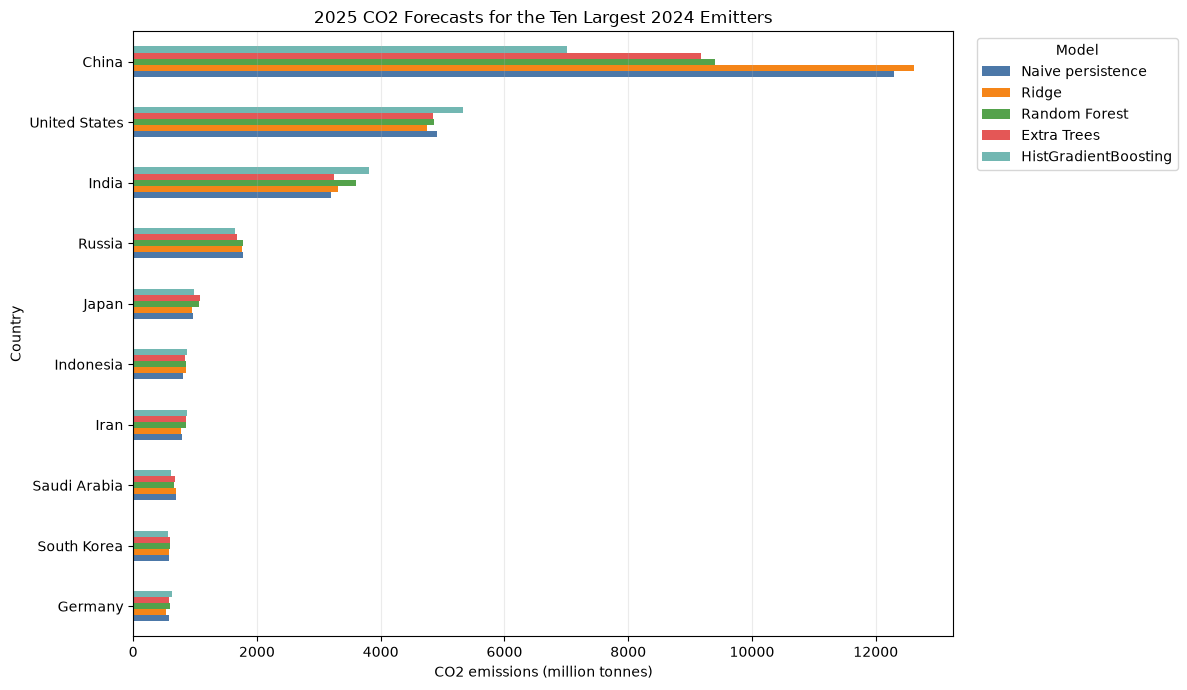

In [120]:
forecast_model_columns = [
    'Naive persistence',
    'Ridge',
    'Random Forest',
    'Extra Trees',
    'HistGradientBoosting'
]

bar_colors = ['#4c78a8', '#f58518', '#54a24b', '#e45756', '#72b7b2']

# Compare 2025 forecasts for the ten largest 2024 emitters
largest_emitters = forecast_2025.nlargest(10, 'co2')['country']
top_forecasts = forecast_2025[
    forecast_2025['country'].isin(largest_emitters)
].copy()
top_forecasts = top_forecasts.sort_values('co2', ascending=True)

plot_data = top_forecasts.set_index('country')[forecast_model_columns]

ax = plot_data.plot(
    kind='barh',
    figsize=(12, 7),
    color=bar_colors
)
ax.set_xlabel('CO2 emissions (million tonnes)')
ax.set_ylabel('Country')
ax.set_title('2025 CO2 Forecasts for the Ten Largest 2024 Emitters')
ax.grid(axis='x', alpha=0.25)
ax.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()